# Introduction 
This project is about Exploratory Data Analysis which focuses on identifying business trends across industries, employee distribution, revenue behaviour, compan performance metrics and market related patterns.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("INDUSTRY.csv")

In [19]:
print(df.head())
print(df.tail())

   id  company_name       industry  country  employee_count  \
0   1    FinTrust_1        Finance    India             535   
1   2    TechNova_2     Technology  Germany            3806   
2   3   RetailHub_3         Retail   Canada            2779   
3   4  BuildWorks_4  Manufacturing      USA             835   
4   5    MediCorp_5     Healthcare    India            4490   

   annual_revenue_million  profit_margin_percent  founded_year  \
0                  539.38                  40.42          2010   
1                  852.42                  39.55          2010   
2                  257.11                  23.68          1996   
3                  309.14                  31.31          1993   
4                  988.68                  43.65          1996   

   customer_count  market_rating created_date         region  
0           81191            0.7   13-10-2025           Asia  
1           92162            3.4    1/12/2025         Europe  
2           27532            2.9   

In [20]:
print("columns:",df.shape[0])
print("Rows:",df.shape[1])

columns: 15000
Rows: 12


In [21]:
df["created_date"].head(20)

0     13-10-2025
1      1/12/2025
2       4/5/2025
3       1/2/2026
4     29-06-2025
5     15-05-2024
6     31-10-2024
7      7/10/2025
8     19-04-2025
9      3/12/2025
10    30-05-2024
11    19-06-2025
12    25-07-2024
13    24-02-2024
14    21-08-2024
15      4/8/2024
16      3/3/2025
17      2/2/2024
18    28-01-2025
19     5/12/2024
Name: created_date, dtype: str

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  str    
 2   industry                15000 non-null  str    
 3   country                 15000 non-null  str    
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  str    
 11  region                  15000 non-null  str    
dtypes: float64(3), int64(4), str(5)
memory usage: 1.4 MB


# Changing data types
- created_date: from str to datetime
- founded_year: from int to str

In [23]:
df["craeted_date"] = pd.to_datetime(
    df["created_date"].str.replace("-","/"),
    dayfirst=True,
    format="mixed"
)
df["founded_year"] = df["founded_year"].astype(str)

## Checking data types again

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      15000 non-null  int64         
 1   company_name            15000 non-null  str           
 2   industry                15000 non-null  str           
 3   country                 15000 non-null  str           
 4   employee_count          15000 non-null  int64         
 5   annual_revenue_million  15000 non-null  float64       
 6   profit_margin_percent   15000 non-null  float64       
 7   founded_year            15000 non-null  str           
 8   customer_count          15000 non-null  int64         
 9   market_rating           15000 non-null  float64       
 10  created_date            15000 non-null  str           
 11  region                  15000 non-null  str           
 12  craeted_date            15000 non-null  datetime64[us]
dt

## Missing values

In [25]:
df.isnull().sum()

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
craeted_date              0
dtype: int64

In [26]:
df.describe()

,id,employee_count,annual_revenue_million,profit_margin_percent,customer_count,market_rating,craeted_date
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000
mean,7500.500000,2606.862067,549.732707,25.012019,50449.251867,2.513780,2025-01-28 08:41:57.120000
min,1.000000,100.000000,50.160000,5.000000,500.000000,0.000000,2024-01-01 00:00:00
25%,3750.750000,1379.000000,299.915000,15.050000,25676.250000,1.200000,2024-07-14 00:00:00
50%,7500.500000,2587.000000,543.920000,24.910000,50726.500000,2.500000,2025-01-28 00:00:00
75%,11250.250000,3839.000000,797.570000,35.100000,75271.250000,3.800000,2025-08-12 00:00:00
max,15000.000000,5099.000000,1049.960000,45.000000,100495.000000,5.000000,2026-02-28 00:00:00
std,4330.271354,1430.562513,288.244128,11.526187,28744.638830,1.447998,NaN


# Univariate Analysis
Univariate analysis is the simplest form of data analysis — it looks at one variable at a time to understand its characteristics.

Purpose:
-Summarize data

-Understand distribution, central tendency, spread

-Detect outliers

Mean: 2606.8620666666666
Skewness: 0.0023535190865822068
Kurtosis: -1.1876950556521884
Standard Deviation: 1430.5625126902273
Maximum Value: 5099
Minimum Value: 100


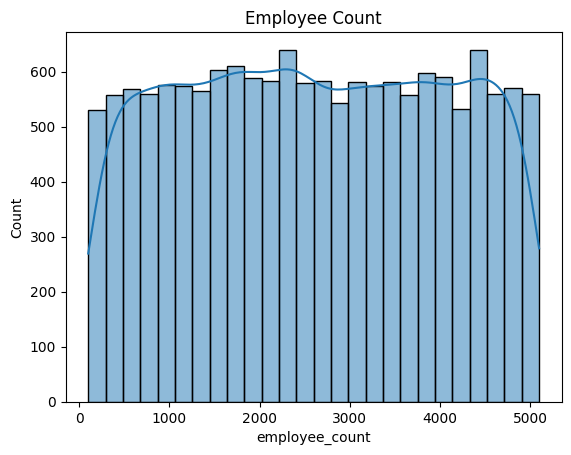

In [27]:
print("Mean:",df["employee_count"].mean())
print("Skewness:",df["employee_count"].skew())
print("Kurtosis:",df["employee_count"].kurt())
print("Standard Deviation:",df["employee_count"].std())
print("Maximum Value:",df["employee_count"].max())
print("Minimum Value:",df["employee_count"].min())

sns.histplot(df["employee_count"],kde=True)
plt.title("Employee Count")
plt.show()

**Insights**
- The skewness is 0.0023 e.i. near to 0 which indivated that employee count has perfectly symmetric distribution.
- Employee count is evenly distributed among entire range.

- The Kurtosis is -1.18. Negative means it is a platykurtic distribution. 
- It has no such outliers.

- the Maximum number of employees is 5099 which indicates that the data could be of small to medium sized companies. 

Mean: 50449.251866666666
Skewness: -0.004865927723658375
Kurtosis: -1.1947135992732307
Standard Deviation: 28744.63883020963
Maximum Value: 100495
Minimum Value: 500


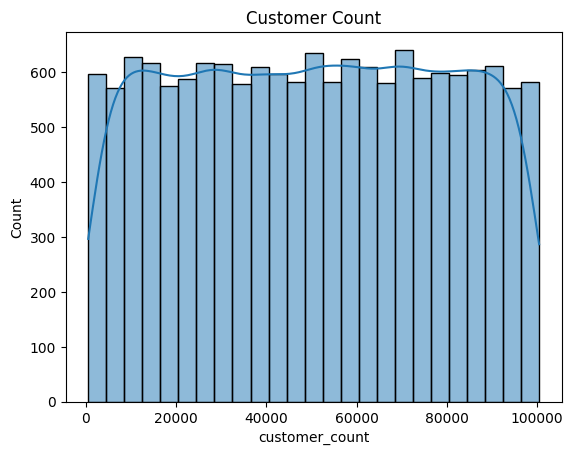

In [28]:
print("Mean:",df["customer_count"].mean())
print("Skewness:",df["customer_count"].skew())
print("Kurtosis:",df["customer_count"].kurt())
print("Standard Deviation:",df["customer_count"].std())
print("Maximum Value:",df["customer_count"].max())
print("Minimum Value:",df["customer_count"].min())

sns.histplot(df["customer_count"],kde=True)
plt.title("Customer Count")
plt.show()

**Insights**
- The Skewness is 0.0048 e.i. near to 0 which indicates that customer count has perfectly symmetric distribution.
- Customer count is evenly distributed among entire range.

- The Kurtosis is -1.19. Negative means it is a platykurtic distribution. 
- It has no such outliers.

- The Maximum number of customers 100495 which indicates that the company has the large potential revenue.

Mean: 2.5137799999999997
Skewness: -0.020033468814409695
Kurtosis: -1.2057607795157776
Standard Deviation: 1.4479976604775011
Maximum Value: 5.0
Minimum Value: 0.0


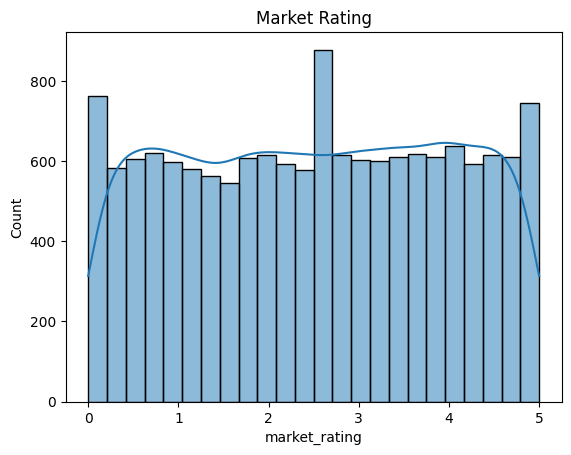

In [29]:
print("Mean:",df["market_rating"].mean())
print("Skewness:",df["market_rating"].skew())
print("Kurtosis:",df["market_rating"].kurt())
print("Standard Deviation:",df["market_rating"].std())
print("Maximum Value:",df["market_rating"].max())
print("Minimum Value:",df["market_rating"].min())

sns.histplot(df["market_rating"],kde=True)
plt.title("Market Rating")
plt.show()

**Insights**
- The companies have an average rating of 2.5 and got very less rating as "5" which indicated the customers are not much satisfied.
- Sufficient room still exists for improvement.
- The comapnies need to come up woth more new ideas of branding and marketing.

- The Skewness and Kurtosis are 0.020 and -1.205 respectively which indicates that the data is spread evenly in the range.

Mean: 549.7327066666667
Skewness: 0.027341229189337332
Kurtosis: -1.1870590784106316
Standard Deviation: 288.24412840517317
Maximum Value: 1049.96
Minimum Value: 50.16


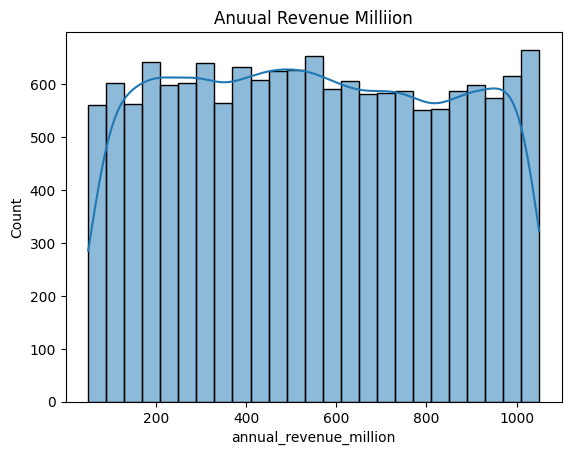

In [30]:
print("Mean:",df["annual_revenue_million"].mean())
print("Skewness:",df["annual_revenue_million"].skew())
print("Kurtosis:",df["annual_revenue_million"].kurt())
print("Standard Deviation:",df["annual_revenue_million"].std())
print("Maximum Value:",df["annual_revenue_million"].max())
print("Minimum Value:",df["annual_revenue_million"].min())

sns.histplot(df["annual_revenue_million"],kde=True)
plt.title("Anuual Revenue Milliion")
plt.show()

**Insights**
- Assuming that the values provided are in the millions of currency units. The maximum revenue a comapny has earned is about 1049.96 millions.
- The Skewness and Kurtosis of Annual Revenue is 0.027 and -1.187 respectively which shows that the data does not have much outliers and is spread evenly.
- The mean is 549 and the standard deviation is 288 which shows that there is a high degree of dispersion.

Mean: 25.01201933333333
Skewness: 0.0025603474408797742
Kurtosis: -1.2025661193949442
Standard Deviation: 11.526186847110734
Maximum Value: 45.0
Minimum Value: 5.0


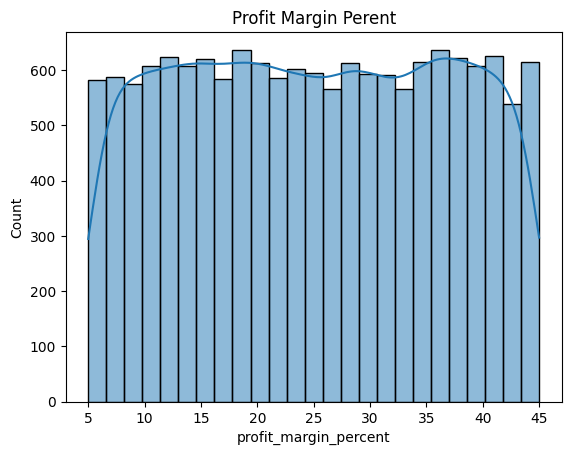

In [31]:
print("Mean:",df["profit_margin_percent"].mean())
print("Skewness:",df["profit_margin_percent"].skew())
print("Kurtosis:",df["profit_margin_percent"].kurt())
print("Standard Deviation:",df["profit_margin_percent"].std())
print("Maximum Value:",df["profit_margin_percent"].max())
print("Minimum Value:",df["profit_margin_percent"].min())

sns.histplot(df["profit_margin_percent"],kde=True)
plt.title("Profit Margin Perent")
plt.show()

**Insights**
- The maximum profit margin is 45%.
- Since the Skewness is near 0 so it shows that the data is evenly spread. 

## Boxplpot

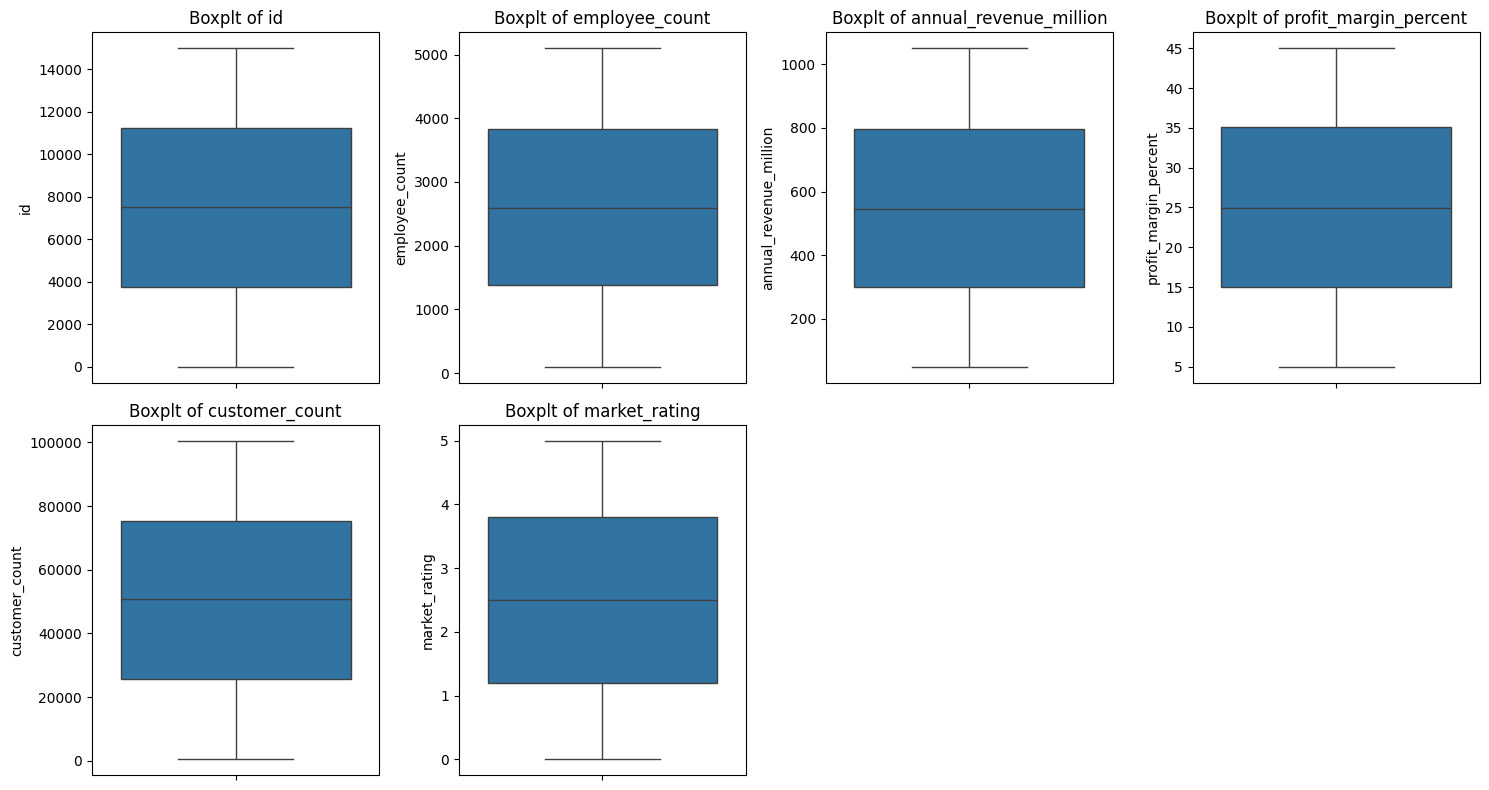

In [32]:
numeric_col = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15,8))
for i , col in enumerate(numeric_col,1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplt of {col}")
plt.tight_layout()
plt.show()


## **No outliers**

## Categorical Data

<Axes: >

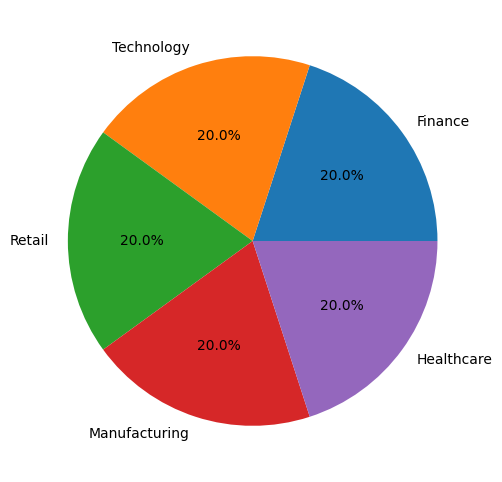

In [33]:
df["profit_margin_percent"].value_counts()
df["industry"].value_counts().plot(
    kind = "pie",
    autopct="%1.1f%%",
    figsize= (6,6)
    )

**Insights**
- The profit in the company has been earned equally by each industry.
- No industry dominates thr dataset.
- The balanced structure minimizes industry bias and facilitates accurate cross-sector comparisons.

<Axes: >

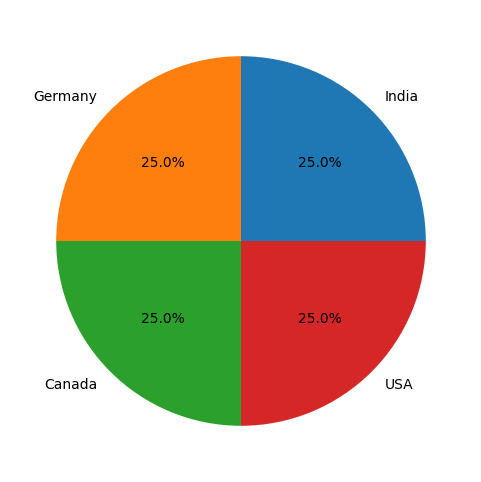

In [34]:
df["profit_margin_percent"].value_counts()
df["country"].value_counts().plot(
    kind = "pie",
    autopct="%1.1f%%",
    figsize= (6,6)
    )

**Insights**
- Each of the four companies have the equal profit margin percent i.e. 25% which shows that the demand of product is equal alll over the conutries where the products are being supplied.
- Since the result is good and equal then the company can ponder upon opening a new branch or exploring a new country with their product.

<Axes: >

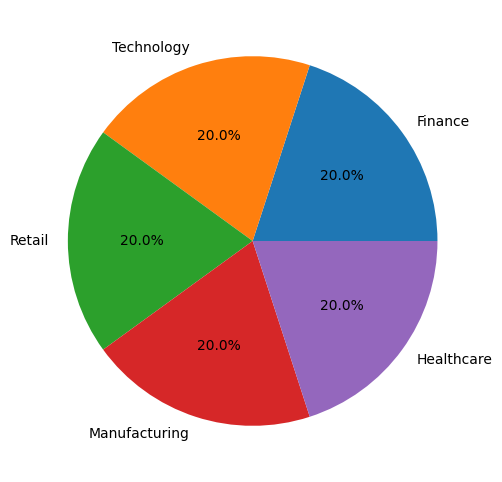

In [35]:
df["customer_count"].value_counts()
df["industry"].value_counts().plot(
    kind = "pie",
    autopct="%1.1f%%",
    figsize= (6,6)
    )

## **Insights**
- The demand of products is same in each industry.
- No industry dominates the dataset.


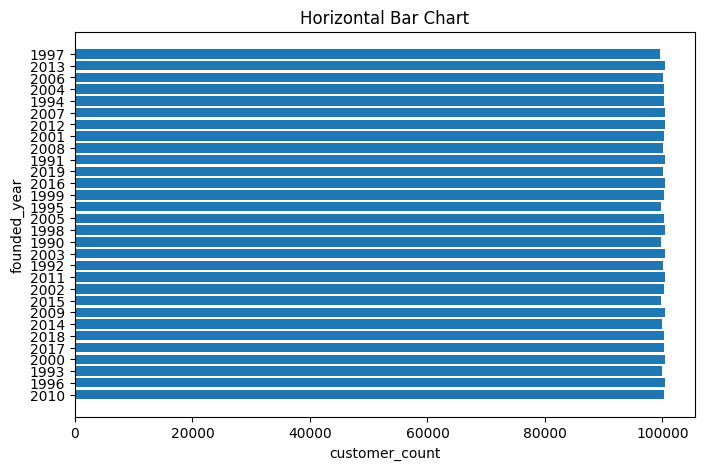

In [36]:
plt.figure(figsize=(8, 5))
plt.barh(df['founded_year'], df['customer_count'])

plt.xlabel('customer_count')
plt.ylabel('founded_year')
plt.title('Horizontal Bar Chart')
plt.show()

**Insights**
- No Strong Relationship Between Company Age and Customer Base.
- Older companies do not appear to have a significant advantage in customer acquisition compared to newer companies.
- Since all the companies have almost equal amount of customer count, the growth oppotunities may be limited.
- No compamy dominates the market.

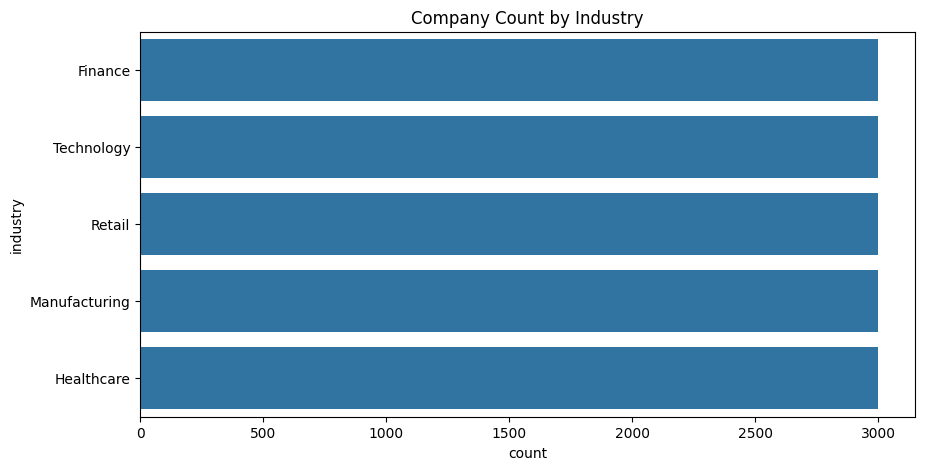

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='industry',
    data=df,
    order=df['industry'].value_counts().index
)
plt.title('Company Count by Industry')
plt.show()

**Insights**
- No Strong Relationship Between Company and Industry.
- Older companies do not appear to have a significant advantage in customer acquisition compared to newer companies.
- Since all the companies have almost equal amount of customer count, the growth oppotunities may be limited.
- No industry dominates the market.

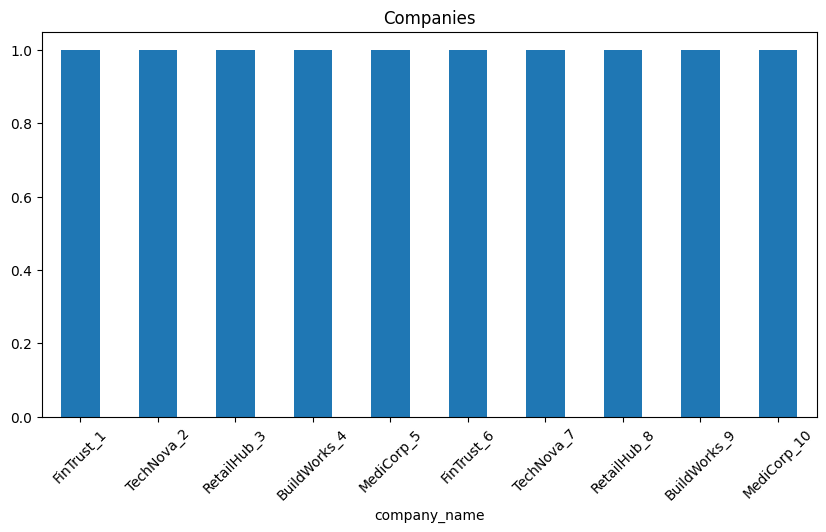

In [38]:
plt.figure(figsize=(10,5))
df["company_name"].value_counts().head(10).plot(kind='bar')
plt.title(f'Companies')
plt.xticks(rotation=45)
plt.show()


**Insights**
- All the companies have similar demand.
- No company dominates the market.
- Since all the comapnies are at same level then this may mean either the competition is huge or the companies have not explored the full potential of market yet.

## Bivariate Analysis
Bivariate analysis means studying two variables at the same time to see:

- if they are related
- how strongly they are related
-and in what direction (positive/negative)

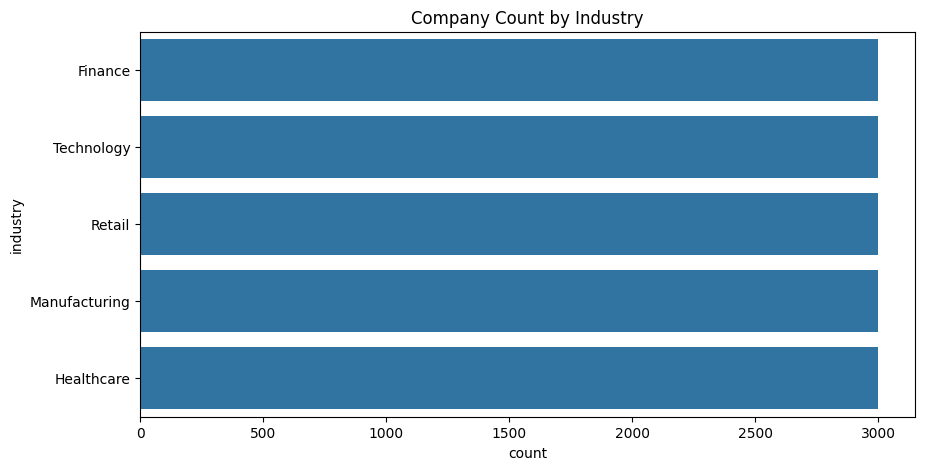

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='industry',
    data=df,
    order=df['industry'].value_counts().index
)
plt.title('Company Count by Industry')
plt.show()

**Insights**
- Perfectly balanced dataset.
- There is no dominant industry in terms of company count.
- Since all the industries contribute the same so the change in the revenue could be due to other factors.

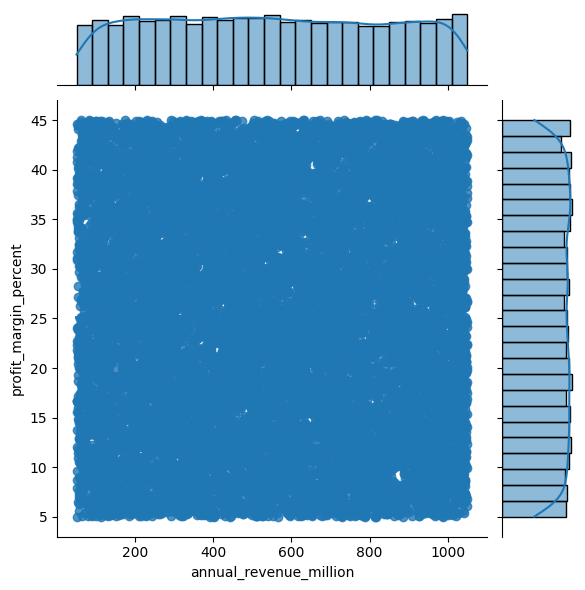

In [40]:
sns.jointplot(
    x='annual_revenue_million',
    y='profit_margin_percent',
    data=df,
    kind='reg',
    height=6
)
plt.show()

**Insights**
- No strong relatioship between revenue and profit margin.
- This shows annual revenue does not influence the profit margin.
- Profit margins are in between the range 5 to 45.
- No major Outliers

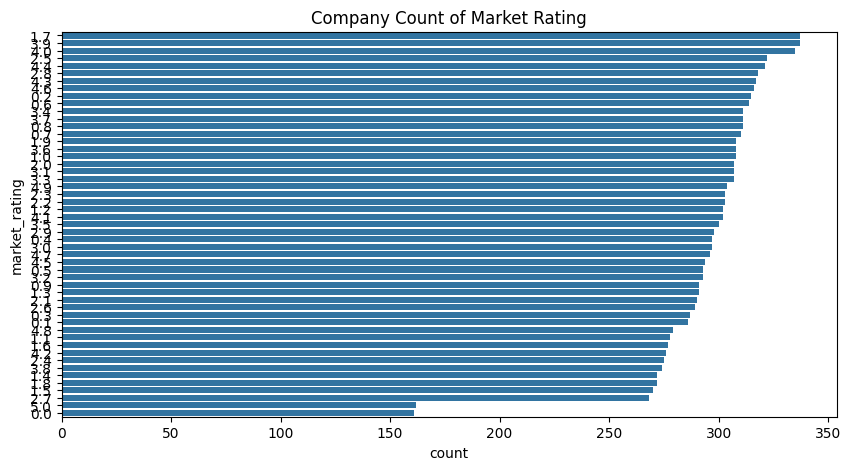

In [41]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='market_rating',
    data=df,
    order=df['market_rating'].value_counts().index
)
plt.title('Company Count of Market Rating')
plt.show()

**Insights**
- Most rating categories have company counts between 250 and 350.
- No single rating dominates the market.
- More Companies got higher ratings.
- The graph shows unbiased comparative analysis.

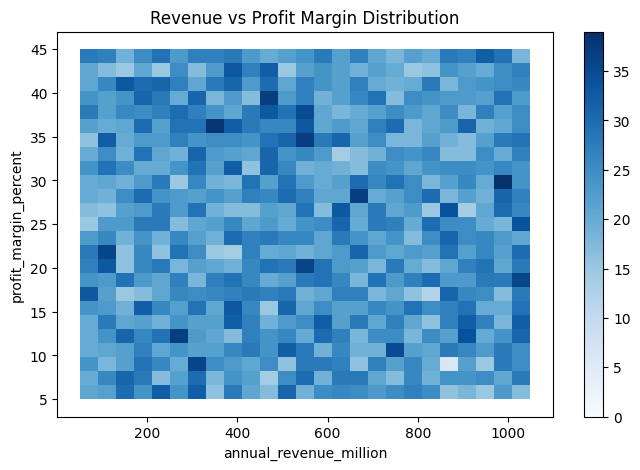

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='annual_revenue_million',
    y='profit_margin_percent',
    cmap='Blues',
    cbar=True
)
plt.title('Revenue vs Profit Margin Distribution')
plt.show()

**Insights**
- No strong relatioship between revenue and profit margin.


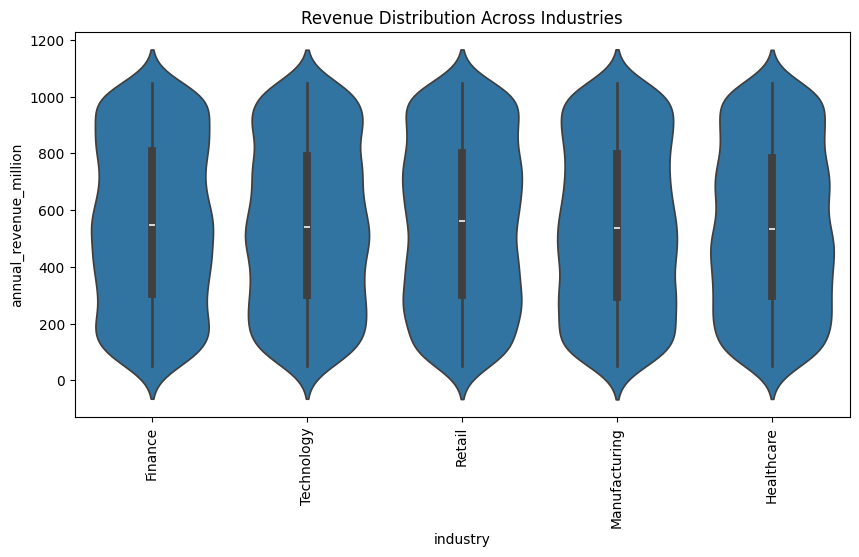

In [43]:
plt.figure(figsize=(10,5))
sns.violinplot(
    x='industry',
    y='annual_revenue_million',
    data=df
)

plt.xticks(rotation=90)
plt.title('Revenue Distribution Across Industries')
plt.show()

**Insights**
- The revenue is generated in the same amount across all industries.
- No industry dominates the Annual revenue pf the company.
- All industries are generating the revenue above 1100 millions.
- More scope for grwoth. 

# Multivariate Analysis
Multivariate Analysis is a statistical technique used to examine the relationships among three or more variables simultaneously. Unlike univariate analysis (one variable) and bivariate analysis (two variables), multivariate analysis helps uncover complex patterns, interactions, and dependencies among multiple variables in a dataset.

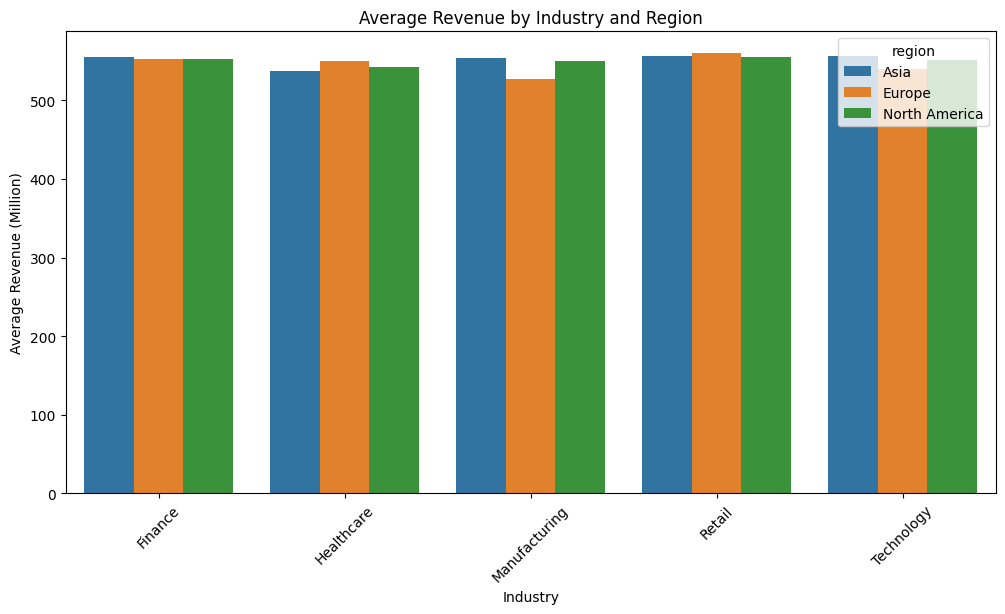

In [44]:
revenue_summary = (
    df.groupby(['industry', 'region'])['annual_revenue_million']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=revenue_summary,
    x='industry',
    y='annual_revenue_million',
    hue='region'
)

plt.xticks(rotation=45)
plt.title('Average Revenue by Industry and Region')
plt.xlabel('Industry')
plt.ylabel('Average Revenue (Million)')
plt.show()

**Insights**
- Finance Industry and Retail Industry are generating maximum revenue in all the concerned countries.
- Manufacturing Industry is proving least revenue among the concerned countries.
- Overall North America has shown the better results in all the industires.
- More attention needd to be paid to Healthcare and Manufacturing industry in Asia and Europe respectively.

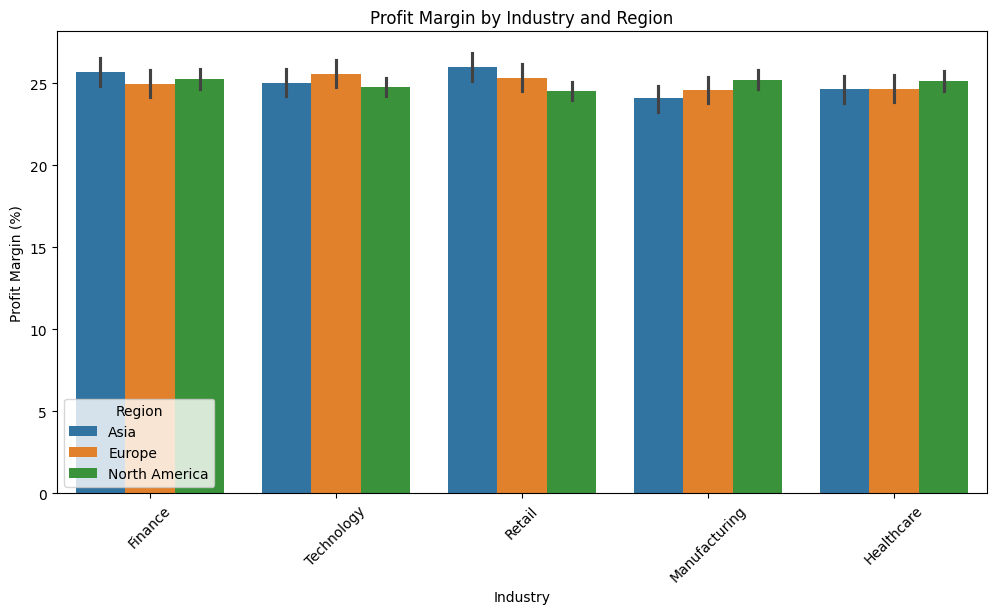

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='industry',
    y='profit_margin_percent',
    hue='region'
)

plt.xticks(rotation=45)
plt.title('Profit Margin by Industry and Region')
plt.xlabel('Industry')
plt.ylabel('Profit Margin (%)')
plt.legend(title='Region')
plt.show()

**Insights**
- Finance Industry and Retail Industry are generating maximum profit margin in all the concerned countries.
- Manufacturing Industry is proving least profit margin among the concerned countries.
- Overall North America has shown the better results in all the industires.
- More attention needd to be paid to Healthcare and Manufacturing industry in Asia and Europe respectively.

# Correlation Analysis

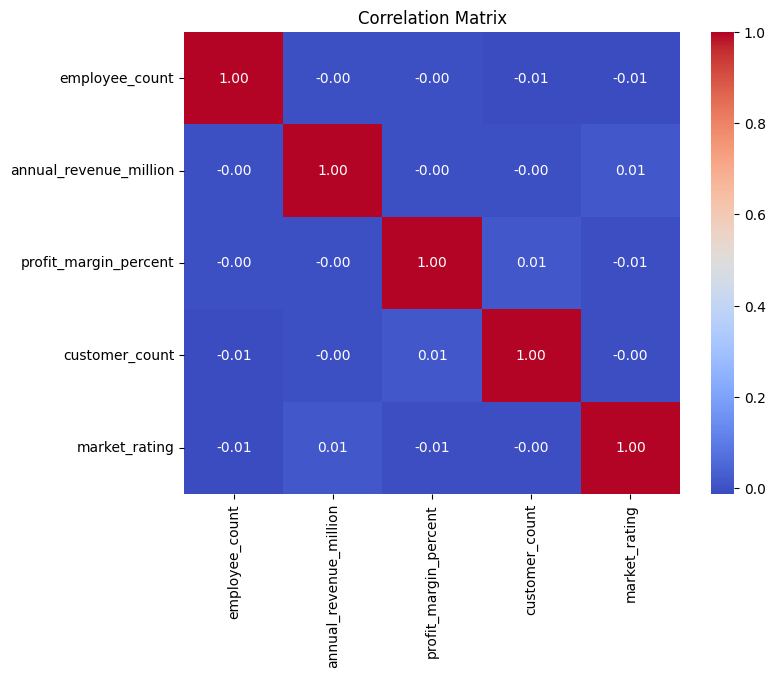

In [46]:
num_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'customer_count',
    'market_rating'
]

plt.figure(figsize=(8,6))
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

**Insights**
- All the variables are independent.
- No variable shows any strong relationship.
- The data is spread uniformly.
- No cluster of data.